In [37]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [39]:
import shutil, os
pycache = r"C:\Users\Rakesh\Documents\summer-project\__pycache__"
if os.path.exists(pycache):
    shutil.rmtree(pycache)
    print("Deleted __pycache__")

In [41]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [43]:
edges, n_vertices, weights = load_graph(r"../../data/raw/power-US-Grid.mtx")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/power-US-Grid.mtx
  Vertices : 4941
  Edges    : 6594
  Weighted : no

n_vertices=4941, edges=6594


In [45]:
check_connectivity(edges, n_vertices)

Components: 1
  -> Graph is fully connected, safe to proceed



1

In [47]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2 — sparse from the start, given graph size
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4941 x 4941
  Degree range: [1, 19]
  Non-zeros in L: 18129

✓ lambda_min = 0.000271
  (eigenvalues found: [0.         0.00027102])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [49]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [51]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [53]:
gamma_in, gamma_out, diameter

([4354,
  4356,
  4357,
  4358,
  4360,
  4363,
  4364,
  4370,
  4371,
  4372,
  4378,
  4379,
  4382,
  4387,
  4390,
  4394,
  4396,
  4402,
  4415,
  4332,
  4339,
  4349,
  4350],
 [3492,
  3493,
  3494,
  3495,
  3496,
  3524,
  3498,
  3499,
  3500,
  3625,
  3733,
  3318,
  3734,
  3451],
 46)

In [55]:
check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 23, gamma_out: 14, n_vertices: 4941
Boundary fraction: 0.7488%
  -> Likely safe for aggregation (comparable to validated successes).


0.00748836267961951

In [57]:
aggregate_of, n_coarse = build_capped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)

In [59]:
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 2074 (2074 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.38
Singletons: 0 (0.0%)
gamma_in_coarse: 15, gamma_out_coarse: 7
Overlap (must be empty): set()
Interior coarse vertices: 2052 (98.9%)


In [61]:
coarse_edges, coarse_contribs = build_coarse_graph_edges(edges, aggregate_of)
print(f"coarse edges: {len(coarse_edges)}")

coarse edges: 3282


saved to us_power_grid_fine_coarse.png


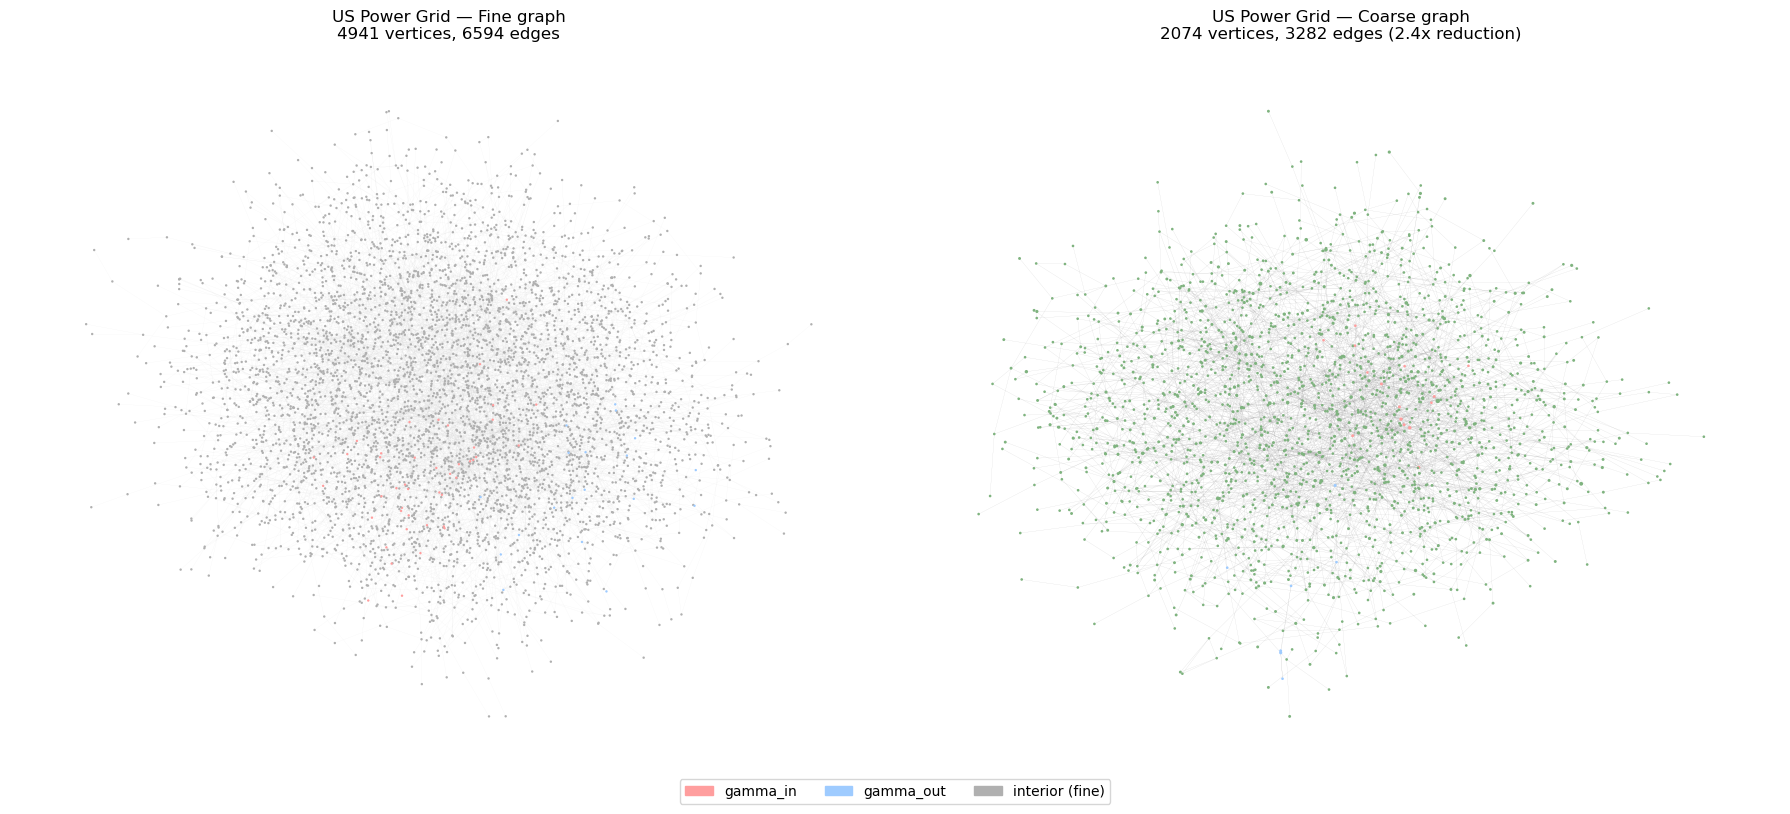

In [30]:
gamma_in_coarse = sorted(set(aggregate_of[v] for v in gamma_in))
gamma_out_coarse = sorted(set(aggregate_of[v] for v in gamma_out))

fig, axes = visualize_fine_and_coarse(
    G_nx, aggregate_of, n_coarse, coarse_edges,
    gamma_in_coarse, gamma_out_coarse,
    dataset_name="US Power Grid",
    save_path="us_power_grid_fine_coarse.png"
)

In [63]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 23, gamma_out: 14, n_vertices: 4941
Boundary fraction: 0.7488%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 2074 (2074 aggregates)
Size distribution -- min: 2, max: 10, mean: 2.38
Singletons: 0 (0.0%)
gamma_in_coarse: 15, gamma_out_coarse: 7
Overlap (must be empty): set()
Interior coarse vertices: 2052 (98.9%)
coarse edges: 3282 (from 6594 fine edges)


In [65]:
result_direct = run_paired_validation(setup, N=300)

Paired samples: 100%|██████████| 300/300 [00:16<00:00, 17.73sample/s, Q_fine=0.1522, Q_coarse=0.2362]


N = 300 paired samples
Q_fine   : mean=0.152167  var=0.000002
Q_coarse : mean=0.236160  var=0.000006
Q_fine - Q_coarse : mean=-0.083994  var=0.000001
Correlation(Q_fine, Q_coarse): 0.9981
Variance reduction: 3.35x


In [ ]:
plot_convergence(result, title="US Power Grid — Convergence (N=100)")

In [67]:
estimate_direct = two_level_estimate(setup, result_direct, N_coarse_only=2000)

Coarse-only samples: 100%|██████████| 2000/2000 [01:04<00:00, 31.09sample/s, Q_coarse=0.2362]


Coarse-only base estimate (N=2000): 0.236208
Correction term mean (paired samples): -0.083994
Two-level estimate of E[Q_fine]: 0.152214
Direct fine-only mean (for comparison): 0.152167
